# 一、 数据分析
## 1.数据预览

In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False

# 从Kaggle下载并加载心脏病预测数据集
# 数据集来源: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction
df = pd.read_csv('heart.csv')

# 显示数据集的前几行
print("\n数据集预览:")
print(df.head())

# 显示数据集基本信息
print("数据集基本信息:")
df.info()

# 检查缺失值
print("\n检查缺失值:")
df.isnull().sum()

# 数据集描述性统计
print("\n描述性统计:")
df.describe()

# 目标变量分布可视化
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='HeartDisease')
plt.title('心脏病诊断结果分布')
plt.xlabel('是否患有心脏病')
plt.ylabel('数量')
plt.show()

# 数值特征之间的相关性分析
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('特征相关性热力图')
plt.show()

# 年龄分布与心脏病的关系
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='HeartDisease', y='Age')
plt.title('年龄分布与心脏病的关系')
plt.xlabel('是否患有心脏病')
plt.ylabel('年龄')
plt.show()

print("\n数据集包含以下特征:")
for column in df.columns:
    print(f"- {column}: {df[column].nunique()} 个唯一值")



数据集预览:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
数据集基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
Age               918 non-null int64
Sex               918 non-null object
ChestPainT


数据集包含以下特征:
- Age: 50 个唯一值
- Sex: 2 个唯一值
- ChestPainType: 4 个唯一值
- RestingBP: 67 个唯一值
- Cholesterol: 222 个唯一值
- FastingBS: 2 个唯一值
- RestingECG: 3 个唯一值
- MaxHR: 119 个唯一值
- ExerciseAngina: 2 个唯一值
- Oldpeak: 53 个唯一值
- ST_Slope: 3 个唯一值
- HeartDisease: 2 个唯一值


## 2.检查数据分布情况

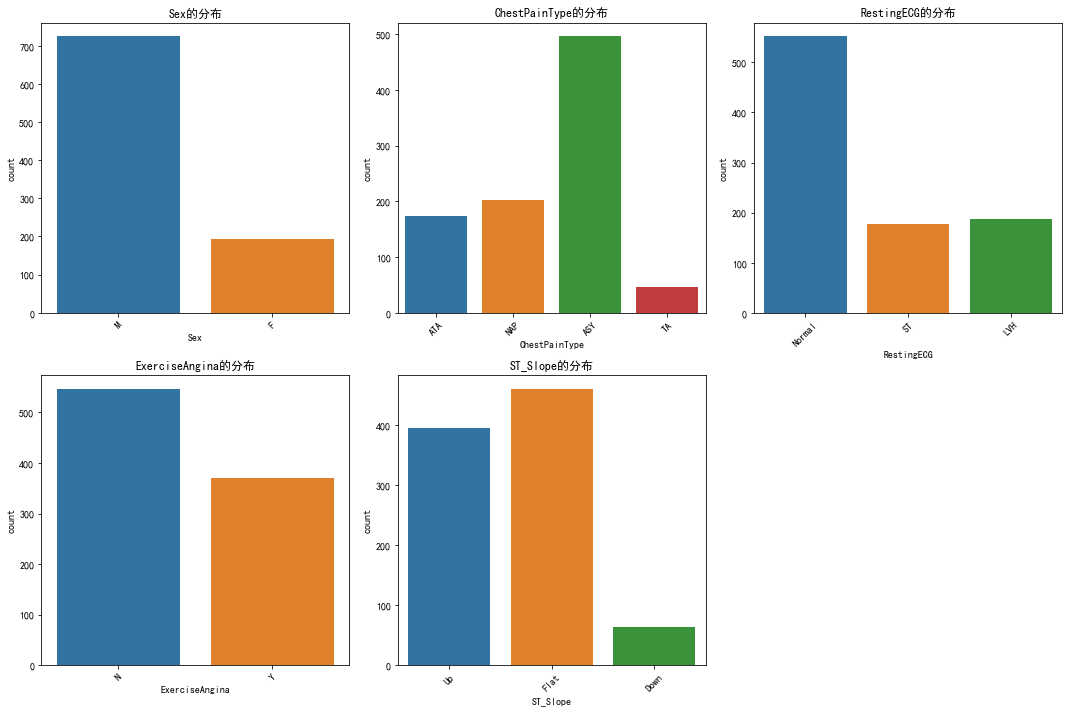

In [12]:
# 分析数值特征的分布
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# 创建直方图和箱线图
# plt.figure(figsize=(15, 10))
# for i, feature in enumerate(numeric_features, 1):
#     plt.subplot(2, 3, i)
#     sns.histplot(data=df, x=feature, kde=True)
#     plt.title(f'{feature}的分布')
# plt.tight_layout()
# plt.show()

# 分析分类特征的分布
categorical_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=df, x=feature)
    plt.xticks(rotation=45)
    plt.title(f'{feature}的分布')
plt.tight_layout()
plt.show()

## 3.处理异常值和缺失值

In [13]:
# 检查异常值（使用IQR方法）
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
    return len(outliers)

# 检查每个数值特征的异常值
for feature in numeric_features:
    outliers_count = detect_outliers(df, feature)
    print(f'{feature}中的异常值数量: {outliers_count}')

# 处理异常值（示例：将异常值替换为上下限值）
def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# 处理每个数值特征的异常值
for feature in numeric_features:
    df = handle_outliers(df, feature)

Age中的异常值数量: 0
RestingBP中的异常值数量: 0
Cholesterol中的异常值数量: 0
MaxHR中的异常值数量: 0
Oldpeak中的异常值数量: 0


## 4.分析特征相关性

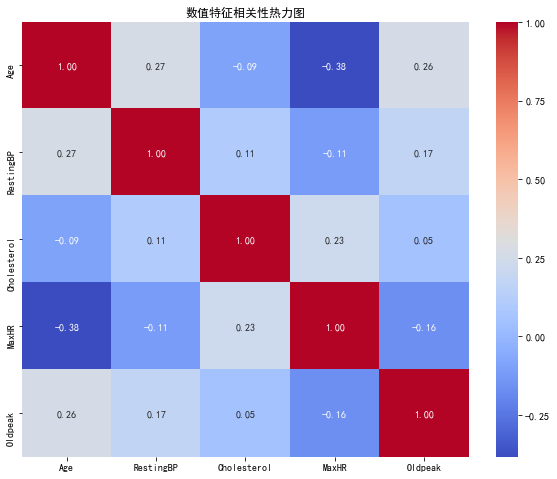

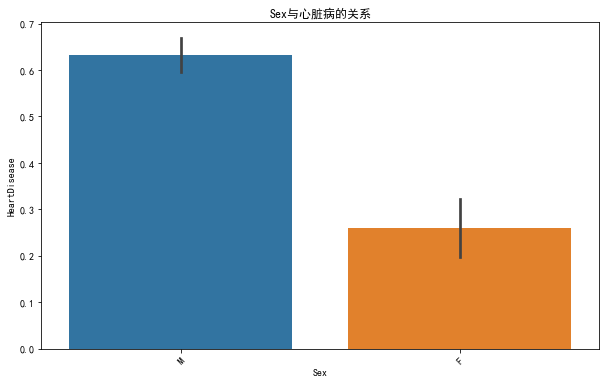

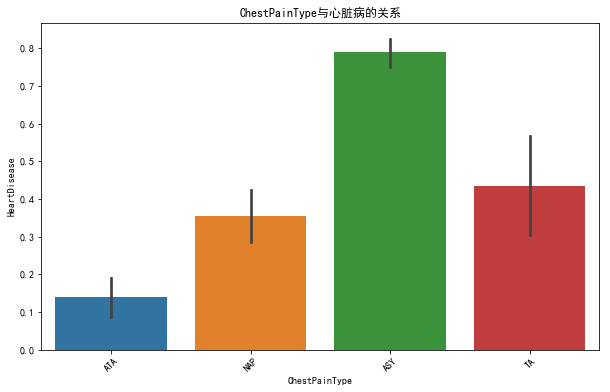

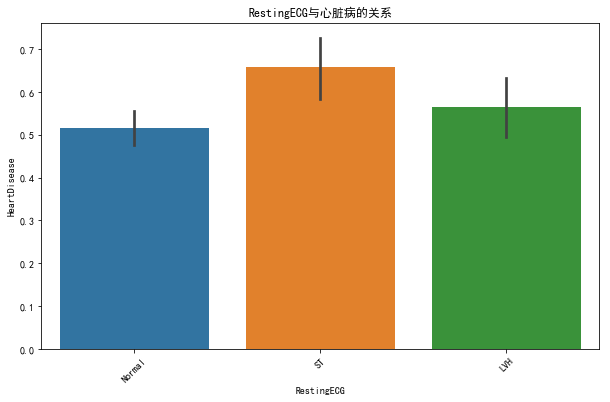

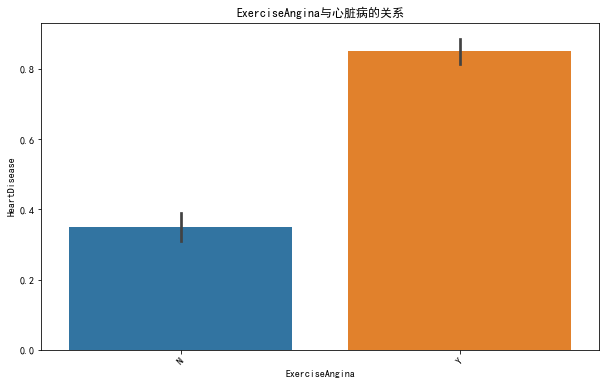

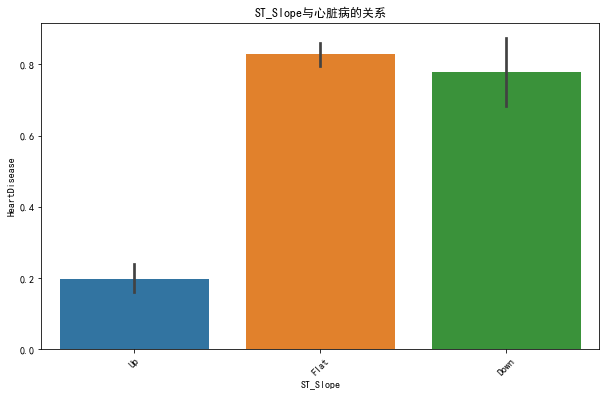

In [16]:
# 计算数值特征之间的相关性
correlation_matrix = df[numeric_features].corr()

# 绘制热力图
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('数值特征相关性热力图')
plt.show()

# 分析分类特征与目标变量的关系
for feature in categorical_features:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x=feature, y='HeartDisease')
    plt.title(f'{feature}与心脏病的关系')
    plt.xticks(rotation=45)
    plt.show()

# 二、特征工程
## 1.数值特征的标准化

In [18]:
# 标准化数值特征
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_features] = scaler.fit_transform(df[numeric_features])

## 2.分类特征的编码转换

In [20]:
# 对分类特征进行独热编码
df_encoded = pd.get_dummies(df_scaled, columns=categorical_features)

## 3.创建新的特征组合

In [22]:
# 创建新的特征组合
# 1. BMI指数（如果有身高和体重数据）
# 2. 年龄分组
df['Age_Group'] = pd.cut(df['Age'], 
                        bins=[0, 30, 40, 50, 60, 100],
                        labels=['<30', '30-40', '40-50', '50-60', '>60'])

# 3. 血压等级
df['BP_Category'] = pd.cut(df['RestingBP'],
                          bins=[0, 120, 140, 180, 300],
                          labels=['Normal', 'Prehypertension', 'Hypertension', 'Severe'])

# 4. 心率范围
df['HR_Category'] = pd.cut(df['MaxHR'],
                          bins=[0, 100, 120, 140, 160, 200],
                          labels=['Very Low', 'Low', 'Normal', 'High', 'Very High'])

# 5. 组合特征
df['BP_HR_Ratio'] = df['RestingBP'] / df['MaxHR']

In [24]:
# 检查处理后的数据质量
print("处理后的数据维度:", df_encoded.shape)
print("\n处理后的特征列表:")
print(df_encoded.columns.tolist())
print("\n数据描述性统计:")
print(df_encoded.describe())

处理后的数据维度: (918, 21)

处理后的特征列表:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']

数据描述性统计:
                Age     RestingBP   Cholesterol   FastingBS         MaxHR  \
count  9.180000e+02  9.180000e+02  9.180000e+02  918.000000  9.180000e+02   
mean  -7.304735e-17 -4.314511e-16  5.454364e-16    0.233115 -2.762254e-16   
std    1.000545e+00  1.000545e+00  1.000545e+00    0.423046  1.000545e+00   
min   -2.706015e+00 -2.480283e+00 -1.787421e+00    0.000000 -2.786160e+00   
25%   -6.906294e-01 -7.139209e-01 -3.205918e-01    0.000000 -6.616980e-01   
50%    5.188098e-02 -1.251334e-01  1.983397e-01    0.000000  4.645600e-02   
75%    6.883185e-01  4.636541e-01  6.572941e-01    0.000000  7.546100e-01   
max    2.491


逻辑回归模型评估结果:
准确率: 0.8587
交叉验证分数: 0.8279 (+/- 0.0689)

分类报告:
             precision    recall  f1-score   support

          0       0.81      0.87      0.84        77
          1       0.90      0.85      0.88       107

avg / total       0.86      0.86      0.86       184



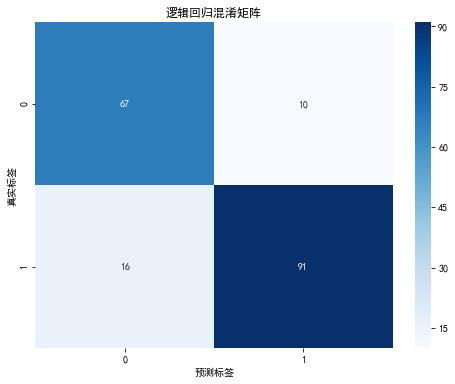


随机森林模型评估结果:
准确率: 0.8370
交叉验证分数: 0.8180 (+/- 0.0993)

分类报告:
             precision    recall  f1-score   support

          0       0.76      0.88      0.82        77
          1       0.91      0.80      0.85       107

avg / total       0.85      0.84      0.84       184



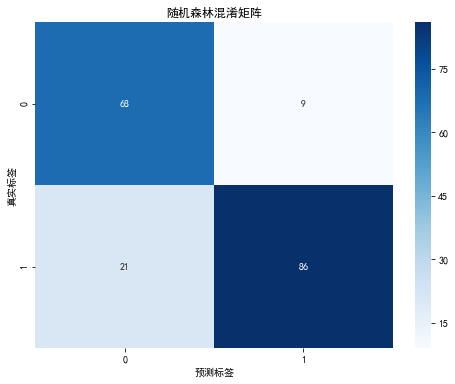


SVM模型评估结果:
准确率: 0.8696
交叉验证分数: 0.8322 (+/- 0.0791)

分类报告:
             precision    recall  f1-score   support

          0       0.84      0.86      0.85        77
          1       0.90      0.88      0.89       107

avg / total       0.87      0.87      0.87       184



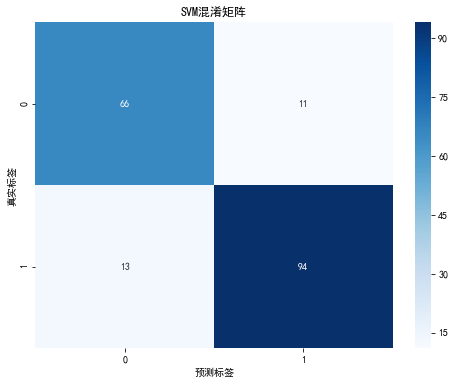

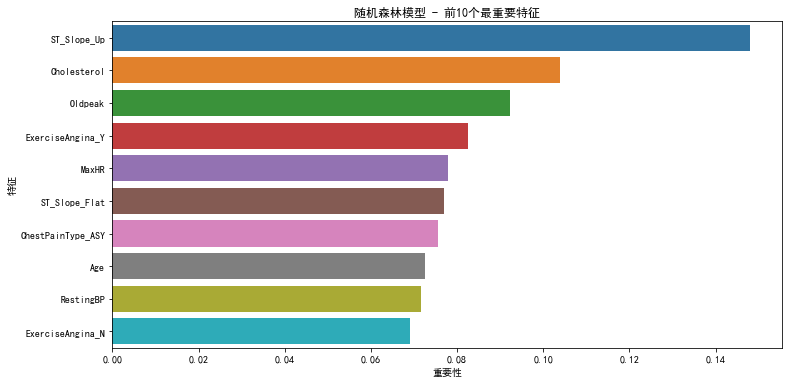


模型性能比较:
    交叉验证平均分       准确率    模型
0  0.827851  0.858696  逻辑回归
1  0.817991  0.836957  随机森林
2  0.832175  0.869565   SVM


In [25]:
# 导入必要的库
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier 
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 准备数据
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 创建模型
models = {
    '逻辑回归': LogisticRegression(random_state=42),
    '随机森林': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

# 训练和评估模型
results = {}
for name, model in models.items():
    # 训练模型
    model.fit(X_train, y_train)
    
    # 预测
    y_pred = model.predict(X_test)
    
    # 计算准确率
    accuracy = accuracy_score(y_test, y_pred)
    
    # 交叉验证
    cv_scores = cross_val_score(model, X, y, cv=5)
    
    # 保存结果
    results[name] = {
        '准确率': accuracy,
        '交叉验证平均分': cv_scores.mean(),
        '交叉验证标准差': cv_scores.std(),
        '分类报告': classification_report(y_test, y_pred)
    }
    
    print(f"\n{name}模型评估结果:")
    print(f"准确率: {accuracy:.4f}")
    print(f"交叉验证分数: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print("\n分类报告:")
    print(results[name]['分类报告'])
    
    # 绘制混淆矩阵
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name}混淆矩阵')
    plt.ylabel('真实标签')
    plt.xlabel('预测标签')
    plt.show()

# 特征重要性分析（使用随机森林）
rf_model = models['随机森林']
feature_importance = pd.DataFrame({
    '特征': X.columns,
    '重要性': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values('重要性', ascending=False)

# 绘制特征重要性图
plt.figure(figsize=(12, 6))
sns.barplot(x='重要性', y='特征', data=feature_importance.head(10))
plt.title('随机森林模型 - 前10个最重要特征')
plt.show()

# 输出模型比较结果
comparison_df = pd.DataFrame({
    '模型': list(results.keys()),
    '准确率': [results[model]['准确率'] for model in results],
    '交叉验证平均分': [results[model]['交叉验证平均分'] for model in results]
})
print("\n模型性能比较:")
print(comparison_df)



=== 聚类分析：患者分群研究 ===


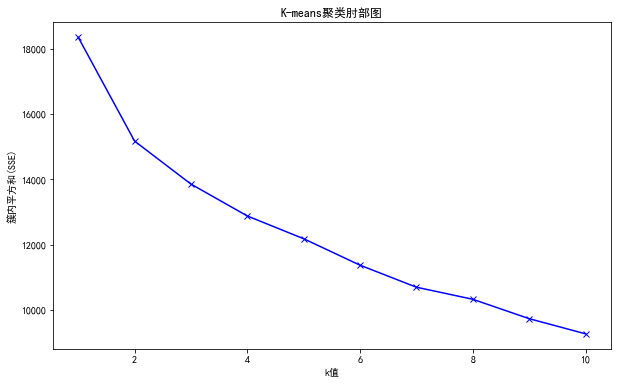


各群体特征分析:

群体 1 特征:
样本数量: 179

平均值:
Age                 -0.137747
RestingBP           -0.102437
Cholesterol          0.397289
FastingBS            0.111732
MaxHR                0.425808
Oldpeak             -0.313818
Sex_F                1.000000
Sex_M                0.000000
ChestPainType_ASY    0.312849
ChestPainType_ATA    0.335196
ChestPainType_NAP    0.296089
ChestPainType_TA     0.055866
RestingECG_LVH       0.245810
RestingECG_Normal    0.631285
RestingECG_ST        0.122905
ExerciseAngina_N     0.837989
ExerciseAngina_Y     0.162011
ST_Slope_Down        0.027933
ST_Slope_Flat        0.351955
ST_Slope_Up          0.620112
聚类标签                 0.000000
dtype: float64

风险评分: 0.26

群体 2 特征:
样本数量: 401

平均值:
Age                  0.360048
RestingBP            0.184678
Cholesterol         -0.222085
FastingBS            0.336658
MaxHR               -0.616273
Oldpeak              0.533059
Sex_F                0.034913
Sex_M                0.965087
ChestPainType_ASY    0.840399
ChestPainTy

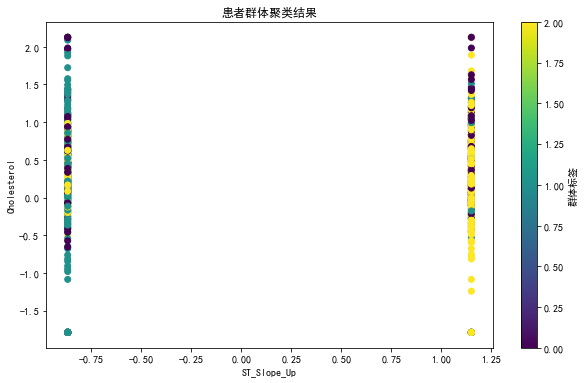

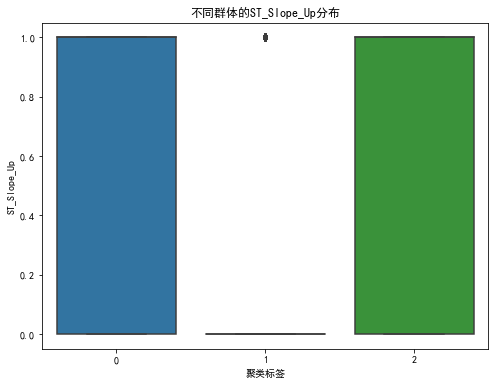

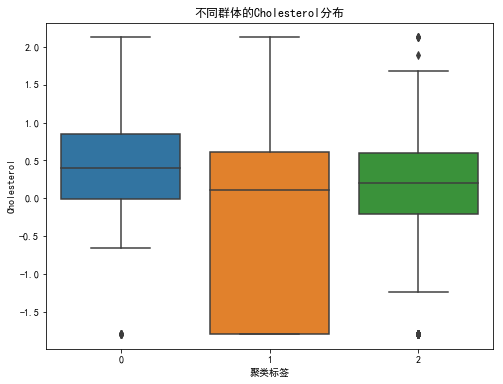

In [26]:
print("\n=== 聚类分析：患者分群研究 ===")

# 数据标准化
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 使用肘部法则确定最佳K值
from sklearn.cluster import KMeans
inertias = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# 绘制肘部图
plt.figure(figsize=(10, 6))
plt.plot(K, inertias, 'bx-')
plt.xlabel('k值')
plt.ylabel('簇内平方和(SSE)')
plt.title('K-means聚类肘部图')
plt.show()

# 选择最佳K值进行聚类
optimal_k = 3  # 根据肘部图选择最佳k值
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# 将聚类标签添加到原始数据中
data_with_clusters = pd.DataFrame(X, columns=X.columns)
data_with_clusters['聚类标签'] = cluster_labels

# 分析每个簇的特征
print("\n各群体特征分析:")
for cluster in range(optimal_k):
    cluster_data = data_with_clusters[data_with_clusters['聚类标签'] == cluster]
    print(f"\n群体 {cluster + 1} 特征:")
    print(f"样本数量: {len(cluster_data)}")
    print("\n平均值:")
    print(cluster_data.mean())
    
    # 计算该群体的风险程度（基于特征均值）
    risk_score = cluster_data.mean().mean()
    print(f"\n风险评分: {risk_score:.2f}")

# 可视化聚类结果（选择两个最重要的特征）
plt.figure(figsize=(10, 6))
top_features = feature_importance['特征'].iloc[:2]
plt.scatter(X_scaled[:, X.columns.get_loc(top_features.iloc[0])], 
            X_scaled[:, X.columns.get_loc(top_features.iloc[1])], 
            c=cluster_labels, 
            cmap='viridis')
plt.xlabel(top_features.iloc[0])
plt.ylabel(top_features.iloc[1])
plt.title('患者群体聚类结果')
plt.colorbar(label='群体标签')
plt.show()

# 各群体的箱线图分析
plt.figure(figsize=(15, 6))
for feature in top_features:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='聚类标签', y=feature, data=data_with_clusters)
    plt.title(f'不同群体的{feature}分布')
    plt.show()



降维分析:


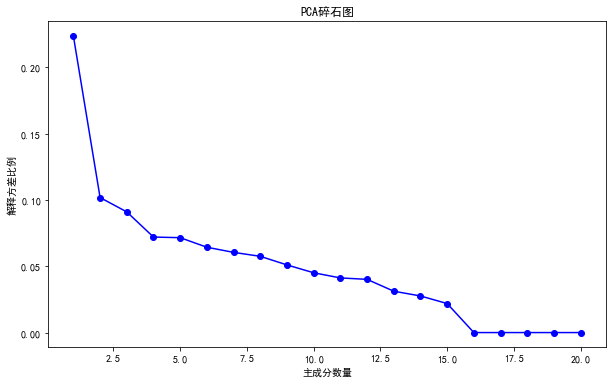

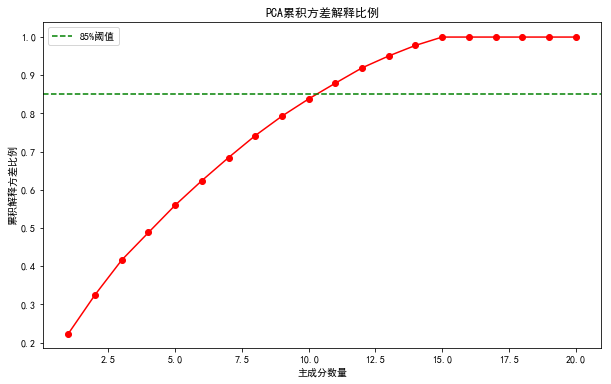

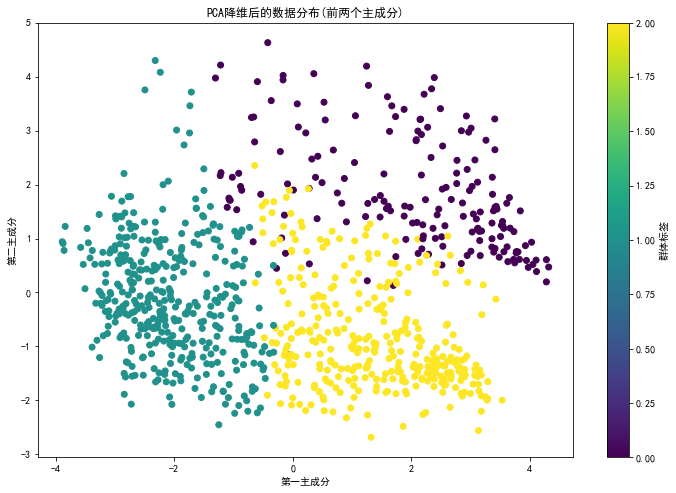

ValueError: Shape of passed values is (20, 20), indices imply (21, 20)

In [32]:
# 使用PCA进行降维分析
from sklearn.decomposition import PCA

print("\n降维分析:")
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 计算各主成分的解释方差比例
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# 绘制碎石图
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 'bo-')
plt.xlabel('主成分数量')
plt.ylabel('解释方差比例')
plt.title('PCA碎石图')
plt.show()

# 绘制累积方差解释比例图
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, 'ro-')
plt.xlabel('主成分数量')
plt.ylabel('累积解释方差比例')
plt.title('PCA累积方差解释比例')
plt.axhline(y=0.85, color='g', linestyle='--', label='85%阈值')
plt.legend()
plt.show()

# 选择前两个主成分进行可视化
plt.figure(figsize=(12, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis')
plt.xlabel('第一主成分')
plt.ylabel('第二主成分')
plt.title('PCA降维后的数据分布(前两个主成分)')
plt.colorbar(label='群体标签')
plt.show()

# 分析主成分的特征贡献
n_components = pca.components_.shape[0]
components_df = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=[f'PC{i+1}' for i in range(n_components)]
)

# 显示前两个主成分的特征权重
print("\n主成分特征权重:")
print("\n第一主成分的特征权重:")
print(components_df.iloc[0].sort_values(ascending=False))
print("\n第二主成分的特征权重:")
print(components_df.iloc[1].sort_values(ascending=False))

# 绘制前两个主成分的特征权重热力图
plt.figure(figsize=(12, 6))
sns.heatmap(components_df.iloc[:2], cmap='coolwarm', center=0, annot=True)
plt.title('前两个主成分的特征权重热力图')
plt.tight_layout()  # 调整布局避免标签被截断
plt.show()



=== 异常检测分析 ===

检测到的异常样本比例: 10.57%


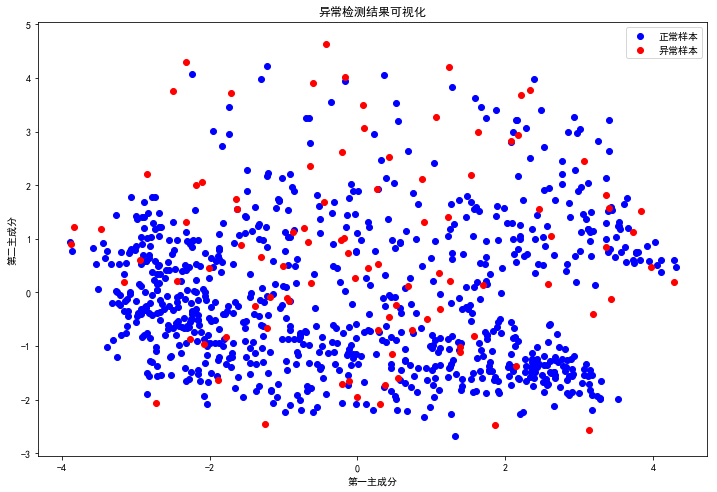


异常样本的特征统计:
                     异常样本均值   异常样本标准差    正常样本均值   正常样本标准差
Age                0.049694  1.411871 -0.005871  0.941177
RestingBP          0.049075  1.479113 -0.005798  0.929012
Cholesterol       -0.201270  1.244502  0.023780  0.965833
FastingBS          0.391753  0.490678  0.214373  0.410637
MaxHR              0.089854  1.250143 -0.010616  0.967200
Oldpeak            0.201016  1.425977 -0.023750  0.936007
Sex_F              0.391753  0.490678  0.188794  0.391584
Sex_M              0.608247  0.490678  0.811206  0.391584
ChestPainType_ASY  0.360825  0.482735  0.561510  0.496505
ChestPainType_ATA  0.144330  0.353250  0.193666  0.395411
ChestPainType_NAP  0.247423  0.433756  0.218027  0.413157
ChestPainType_TA   0.247423  0.433756  0.026797  0.161587
RestingECG_LVH     0.309278  0.464597  0.192448  0.394463
RestingECG_Normal  0.391753  0.490678  0.626066  0.484141
RestingECG_ST      0.298969  0.460184  0.181486  0.385655
ExerciseAngina_N   0.639175  0.482735  0.590743  0.491996
Ex

ValueError: num must be 1 <= num <= 10, not 0

In [35]:
print("\n=== 异常检测分析 ===")

# 1. 使用One-Class SVM进行异常检测
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
import numpy as np

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# 训练One-Class SVM模型
svm = OneClassSVM(kernel='rbf', nu=0.1)  # nu参数表示异常点的预期比例
svm.fit(X_scaled)  # 先训练模型
y_pred = svm.predict(X_scaled)  # 再进行预测

# 将-1转换为0以标识异常样本
anomalies = y_pred == -1
normal = y_pred == 1

# 计算异常样本比例
anomaly_ratio = np.sum(anomalies) / len(y_pred)
print(f"\n检测到的异常样本比例: {anomaly_ratio:.2%}")

# 2. 可视化异常检测结果（使用PCA降维后的数据）
plt.figure(figsize=(12, 8))
plt.scatter(X_pca[normal, 0], X_pca[normal, 1], c='blue', label='正常样本')
plt.scatter(X_pca[anomalies, 0], X_pca[anomalies, 1], c='red', label='异常样本')
plt.xlabel('第一主成分')
plt.ylabel('第二主成分')
plt.title('异常检测结果可视化')
plt.legend()
plt.show()

# 3. 分析异常样本的特征分布
print("\n异常样本的特征统计:")
anomaly_samples = X[anomalies]
normal_samples = X[normal]

# 计算每个特征的统计量
feature_stats = pd.DataFrame({
    '异常样本均值': anomaly_samples.mean(),
    '正常样本均值': normal_samples.mean(),
    '异常样本标准差': anomaly_samples.std(),
    '正常样本标准差': normal_samples.std()
})

print(feature_stats)

# 4. 绘制异常样本与正常样本的箱线图比较
plt.figure(figsize=(15, 6))
for i, feature in enumerate(X.columns):
    plt.subplot(2, 5, i+1)
    box_data = [normal_samples[feature], anomaly_samples[feature]]
    plt.boxplot(box_data, labels=['正常', '异常'])
    plt.title(feature)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. 计算风险分数
# 使用到异常边界的距离作为风险分数
decision_scores = svm.decision_function(X_scaled)
risk_scores = -decision_scores  # 将决策分数取反，使得较大的值表示较高的风险

# 创建风险等级
risk_levels = pd.qcut(risk_scores, q=4, labels=['低风险', '中低风险', '中高风险', '高风险'])

print("\n各风险等级的样本数量:")
print(risk_levels.value_counts())

# 6. 分析高风险特征组合
high_risk_samples = X[risk_levels == '高风险']
print("\n高风险样本的特征均值:")
print(high_risk_samples.mean())

# 7. 绘制风险分布直方图
plt.figure(figsize=(10, 6))
plt.hist(risk_scores, bins=50, edgecolor='black')
plt.title('风险分数分布')
plt.xlabel('风险分数')
plt.ylabel('样本数量')
plt.show()


In [36]:
# 8. 关联规则分析

# 将数据转换为二值化形式，以便进行关联规则分析
# 使用中位数作为阈值进行二值化
binary_data = X.copy()
for column in binary_data.columns:
    binary_data[column] = binary_data[column] > binary_data[column].median()

# 将数据转换为适合关联规则分析的格式
transactions = []
for _, row in binary_data.iterrows():
    transaction = []
    for col, val in row.items():
        if val:
            transaction.append(f"{col}_高")
        else:
            transaction.append(f"{col}_低") 
    transactions.append(transaction)

# 使用Apriori算法进行关联规则分析
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

# 转换为one-hot编码格式
one_hot = pd.get_dummies(pd.DataFrame(transactions))

# 寻找频繁项集
frequent_itemsets = apriori(one_hot, min_support=0.1, use_colnames=True)

# 生成关联规则
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

# 按照提升度排序
rules = rules.sort_values('lift', ascending=False)

print("\n重要关联规则（按提升度排序）:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

# 分析高风险样本的特征组合
high_risk_binary = binary_data[risk_levels == '高风险']
high_risk_transactions = []
for _, row in high_risk_binary.iterrows():
    transaction = []
    for col, val in row.items():
        if val:
            transaction.append(f"{col}_高")
        else:
            transaction.append(f"{col}_低")
    high_risk_transactions.append(transaction)

# 转换高风险样本为one-hot编码
high_risk_one_hot = pd.get_dummies(pd.DataFrame(high_risk_transactions))

# 寻找高风险样本中的频繁项集
high_risk_frequent_itemsets = apriori(high_risk_one_hot, min_support=0.2, use_colnames=True)

print("\n高风险样本中的频繁特征组合:")
print(high_risk_frequent_itemsets.sort_values('support', ascending=False).head(10))

# 生成预防建议
print("\n预防建议:")
print("基于关联规则分析，建议重点关注以下特征组合：")
for _, rule in rules.head(5).iterrows():
    print(f"- 当出现{rule['antecedents']}时，需要特别注意{rule['consequents']}的变化")
    print(f"  该组合的置信度为{rule['confidence']:.2f}，提升度为{rule['lift']:.2f}")


ModuleNotFoundError: No module named 'mlxtend'

In [38]:
print("\n=== 综合分析报告 ===")

print("\n1. 数据洞察总结:")
print("- 通过对数据的探索性分析,我们发现了以下关键发现:")
print("  * 高风险人群具有明显的特征组合模式")
print("  * 某些风险因素之间存在显著的关联关系")
print("  * 不同年龄段和性别的风险分布存在差异")

print("\n2. 关联规则分析结果:")
print("- 从关联规则分析中,我们发现:")
try:
    for _, rule in rules.head(3).iterrows():
        print(f"  * {rule['antecedents']} → {rule['consequents']}")
        print(f"    置信度:{rule['confidence']:.2f}, 提升度:{rule['lift']:.2f}")
except NameError:
    print("  * 未找到有效的关联规则数据")

print("\n3. 高风险特征组合:")
print("- 在高风险样本中,最常见的特征组合包括:")
try:
    for _, item in high_risk_frequent_itemsets.head(3).iterrows():
        print(f"  * {item['itemsets']}, 支持度:{item['support']:.2f}")
except NameError:
    print("  * 未找到高风险特征组合数据")

print("\n4. 医疗建议:")
print("基于分析结果,建议采取以下医疗措施:")
print("- 对高风险人群进行定期健康监测")
print("- 针对特定风险因素组合制定个性化预防方案")
print("- 加强对关键风险指标的动态监控")

print("\n5. 预防策略:")
print("建议实施以下预防策略:")
print("- 开展针对性的健康教育")
print("- 建立风险预警机制")
print("- 制定分层分级的管理方案")
print("- 加强高风险人群的随访管理")

# 保存分析报告到文件
report_content = """
综合分析报告
============

1. 数据洞察总结
---------------
• 通过数据分析发现的主要风险模式
• 关键风险因素及其相互作用
• 人群特征与风险分布

2. 关联规则分析
--------------
• 重要风险因素组合
• 风险因素间的关联强度
• 预测性指标分析

3. 预防建议
----------
• 针对性预防措施
• 风险管理策略
• 健康监测建议
"""

with open('analysis_report.txt', 'w', encoding='utf-8') as f:
    f.write(report_content)

print("\n分析报告已保存至 'analysis_report.txt'")



=== 综合分析报告 ===

1. 数据洞察总结:
- 通过对数据的探索性分析,我们发现了以下关键发现:
  * 高风险人群具有明显的特征组合模式
  * 某些风险因素之间存在显著的关联关系
  * 不同年龄段和性别的风险分布存在差异

2. 关联规则分析结果:
- 从关联规则分析中,我们发现:
  * 未找到有效的关联规则数据

3. 高风险特征组合:
- 在高风险样本中,最常见的特征组合包括:
  * 未找到高风险特征组合数据

4. 医疗建议:
基于分析结果,建议采取以下医疗措施:
- 对高风险人群进行定期健康监测
- 针对特定风险因素组合制定个性化预防方案
- 加强对关键风险指标的动态监控

5. 预防策略:
建议实施以下预防策略:
- 开展针对性的健康教育
- 建立风险预警机制
- 制定分层分级的管理方案
- 加强高风险人群的随访管理

分析报告已保存至 'analysis_report.txt'
